<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/drafts/Notebook9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

In [2]:
!pip install -q folium geopandas

# Data and the State (DATA 20195/30195)
# Lab 9: Neighborhoods

Based on ["An Extremely Detailed Map of New York City Neighborhoods"](https://www.nytimes.com/interactive/2023/upshot/extremely-detailed-nyc-neighborhood-map.html) (Buchanan et al. 2023)

In [3]:
import json
from math import log

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
from shapely import MultiPolygon

In [4]:
submissions_gdf = gpd.read_file("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_nyt_neighborhood_submissions.geojson")

In [5]:
submissions_gdf

,submission_id,neighborhood,geometry
0,s37680,Rego Park,"POLYGON ((-74.266 40.77571, -74.26758 40.7758,..."
1,s8242,Carroll Gardens,"POLYGON ((-74.18548 40.71266, -74.1855 40.7126..."
2,s19091,Mariners Harbor,"POLYGON ((-74.14712 40.62561, -74.17969 40.632..."
3,s12920,Graniteville,"POLYGON ((-74.15735 40.61335, -74.15739 40.613..."
4,s25108,Rossville,"POLYGON ((-74.2175 40.54655, -74.21751 40.5465..."
...,...,...,...
26577,s2538,Bellerose,"POLYGON ((-73.70212 40.72902, -73.71837 40.726..."
26578,s2521,Bellerose,"POLYGON ((-73.71749 40.74395, -73.71748 40.743..."
26579,s11276,Floral Park,"POLYGON ((-73.71038 40.71526, -73.71954 40.715..."
26580,s2533,Bellerose,"POLYGON ((-73.71354 40.73622, -73.71353 40.736..."


<Axes: >

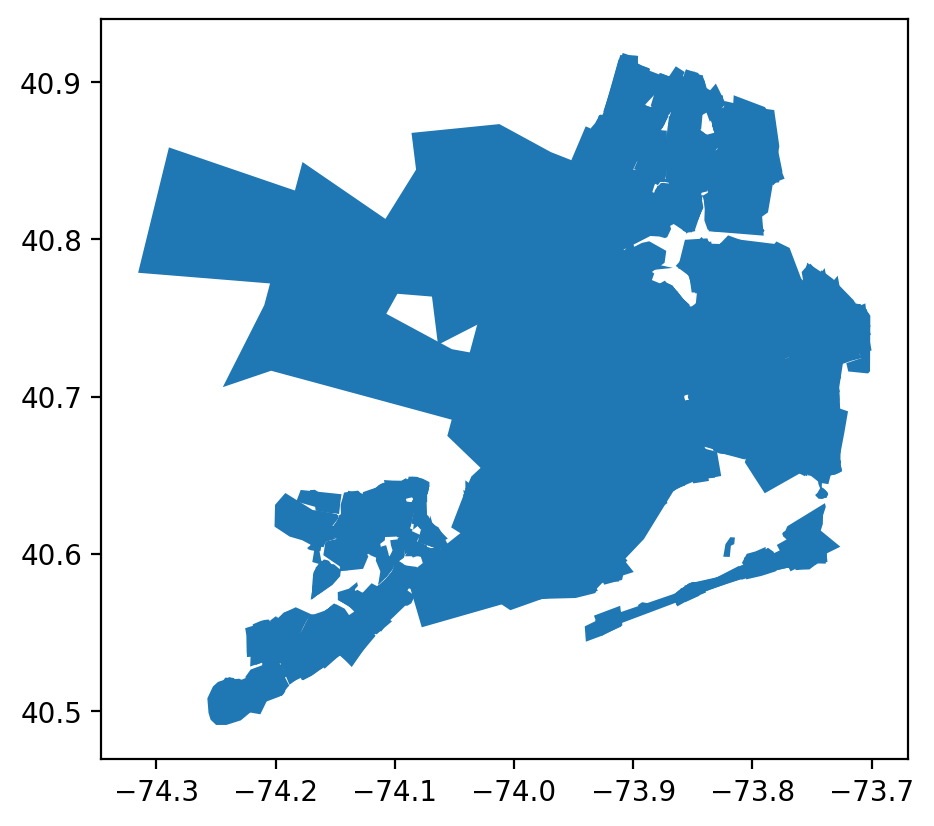

In [6]:
submissions_gdf.plot()

Each submission seems to have one neighborhood label.  These were chosen by the users together with their polygons.  There are 379 neighborhood labels.

In [7]:
submissions_gdf["neighborhood"].value_counts()

,count
neighborhood,
Upper West Side,2095
Park Slope,1033
Upper East Side,1009
East Village,847
West Village,669
...,...
Madison,1
Ravenswood,1
Mount Eden,1


It's not immediately obvious if users got to choose the neighborhood name as free text, or if they got a menu of options.  Let's see all the things called some kind of "village."

In [8]:
submissions_gdf[submissions_gdf["neighborhood"].str.contains("illage")].value_counts("neighborhood")

,count
neighborhood,
East Village,847
West Village,669
Greenwich Village,495
Peter Cooper Village,33
Middle Village,27
The Village,19
Van Cortlandt Village,15
Queens Village,15
Far West Village,11


The relative simplicity of this list strongly suggests that the NYT data folks presented people with this list of options rather than letting them enter their own free text.  Otherwise we'd expect lots of crazy misspellings and what-not!

Let's take a look at all the ones tagged as "Upper West Side"....

In [9]:
submissions_map = folium.Map(
    [40.787, -73.9754],
    zoom_start=13,
    tiles="Cartodb Positron",  # use a less cluttered basemap
)
for _, row in submissions_gdf[submissions_gdf["neighborhood"] == "Upper West Side"].iterrows():
    folium.PolyLine([(y, x) for x, y in row.geometry.exterior.coords], weight=2, opacity=0.5).add_to(submissions_map)

In [10]:
submissions_map

Amusingly, a few people don't know their East from West.... and one person is on the wrong land mass altogether.  These are the pleasures of user-submitted data!

The NYT folks did some processing, and in particular they worked out how often each census block got each tag.

In [11]:
!curl -O https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_nyt_neighborhood_block_weights.json

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3022k  100 3022k    0     0  6646k      0 --:--:-- --:--:-- --:--:-- 6657k


In [12]:
with open("Notebook9_nyt_neighborhood_block_weights.json", 'r') as f:
    block_weights = json.load(f)

In [13]:
list(block_weights.items())[:10]  # Census block GEOID -> neighborhood weights

[('360850323001008', {'Mariners Harbor': 0.514, 'Graniteville': 0.486}),
 ('360850323001007', {'Mariners Harbor': 0.515, 'Graniteville': 0.485}),
 ('360850323001005',
  {'Mariners Harbor': 0.393, 'Graniteville': 0.312, 'Elm Park': 0.295}),
 ('360850323001006',
  {'Mariners Harbor': 0.361, 'Graniteville': 0.349, 'Elm Park': 0.29}),
 ('360850323001011',
  {'Mariners Harbor': 0.35, 'Graniteville': 0.362, 'Elm Park': 0.288}),
 ('360850323001004', {'Mariners Harbor': 0.589, 'Elm Park': 0.411}),
 ('360850323001012',
  {'Mariners Harbor': 0.35, 'Graniteville': 0.362, 'Elm Park': 0.288}),
 ('360850291021034', {'Bulls Head': 0.83, 'Graniteville': 0.17}),
 ('360850323001020',
  {'Mariners Harbor': 0.319, 'Graniteville': 0.362, 'Elm Park': 0.319}),
 ('360850291022019', {'Travis': 1})]

## Neighborhood cores

In [14]:
!curl -O https://www2.census.gov/geo/tiger/TIGER2024/TABBLOCK20/tl_2024_36_tabblock20.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  181M  100  181M    0     0   108M      0  0:00:01  0:00:01 --:--:--  108M


In [15]:
block_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/TABBLOCK20/tl_2024_36_tabblock20.zip").set_index("GEOID20")

There are (at least) two ways of thinking about the level of disagreement.

Definition 1: of the submissions that include `block X`, what share labeled it as `neighborhood Y`? (in other words: what do New Yorkers call this block?)

Definition 2: of the submissions that are labeled with `neighborhood Y`, what share include `block X`? (in other words: among the people with an opinion on where that neighborhood is, do they include this block?)



So now we'll define a `core` function, which lets you choose a neighborhood and then picks all the blocks where at least `cutoff` share of submitters gave it that label.  (You can choose the cutoff!)

Note: This is based on the kind of consensus that's measured in Definition 1 above.

In [16]:
def core(neighborhood, cutoff=0):  # def. (1)
    neighborhood_weights = {
        geoid: weights[neighborhood]
        for geoid, weights in block_weights.items()
        if neighborhood in weights and weights[neighborhood] >= cutoff
    }
    core_gdf = block_gdf.loc[neighborhood_weights.keys()]
    core_gdf["weight"] = neighborhood_weights
    return core_gdf.reset_index()

In [17]:
core_map = folium.Map(
    [40.787, -73.9754],
    zoom_start=13,
    tiles="Cartodb Positron",  # use a less cluttered basemap
)
core_gdf = core("Upper West Side", cutoff=0.1)

folium.Choropleth(
    geo_data=core_gdf,
    data=core_gdf,
    columns=["GEOID20", "weight"],
    key_on="feature.properties.GEOID20",
    fill_color="OrRd",
).add_to(core_map)

Let's visualize (as a heatmap) Definition 1 of "Upper West Side."

In [18]:
core_map

In [19]:
block_neighborhood_counts = {
    geoid: len(weights)
    for geoid, weights in block_weights.items()
}

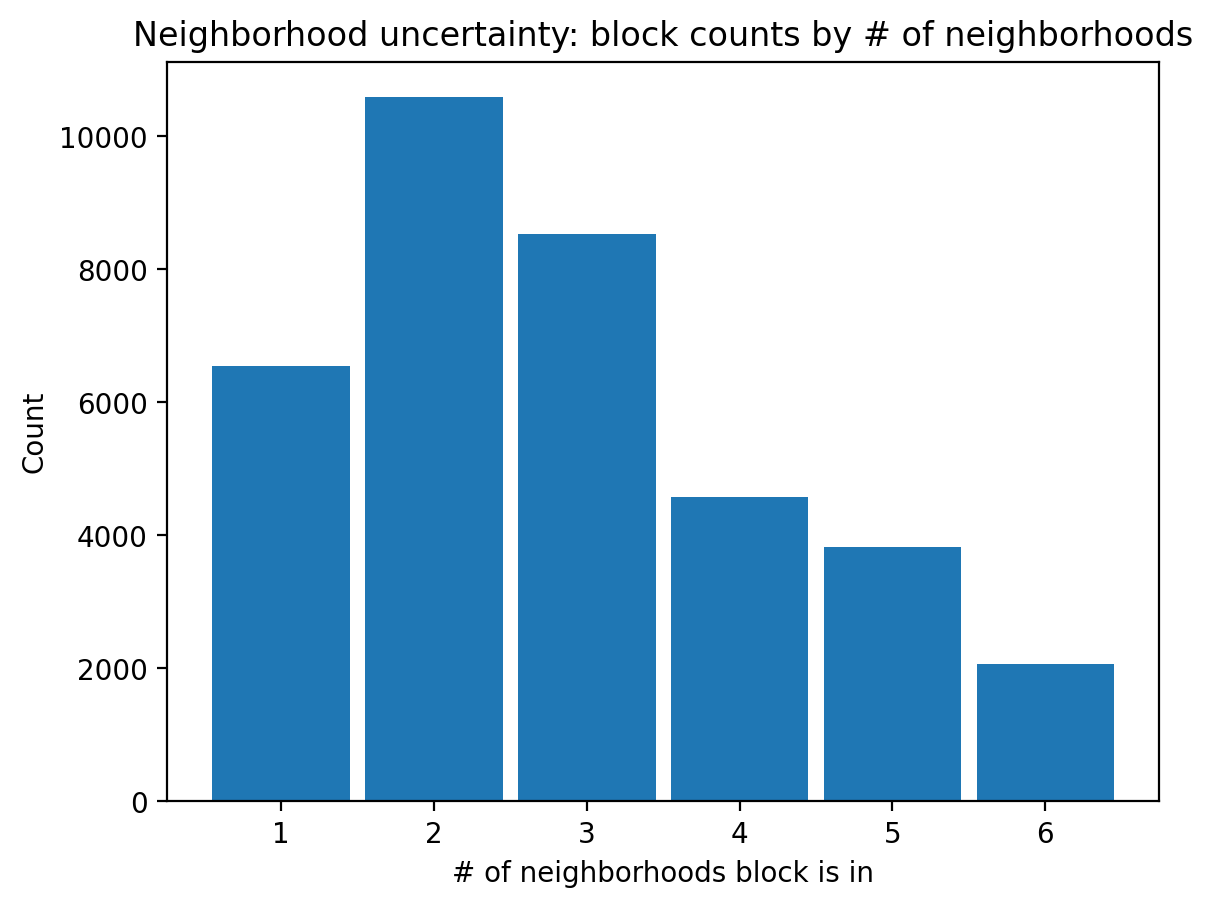

In [20]:
plt.hist(block_neighborhood_counts.values(), bins=np.arange(1, 8)-0.5,rwidth=0.9)
plt.title("Neighborhood uncertainty: block counts by # of neighborhoods")
plt.xlabel("# of neighborhoods block is in")
plt.ylabel("Count")
plt.show()

For each block, we'll sum over its weight vector to get a measure of uncertainty about its neighborhood assignment.  We'll use the math concept called *Shannon entropy*, which was explained in class:  it is made by $H=\sum w_i \log w_i$ over the coordinates $i$.  So if a block is called "West Village" 100 times but "The Village" just once, its Shannon entropy is low, which means there's not significant disagreement.  But if it gets each label 50 times, it gets a higher score $H=1$.  And if it gets THREE labels each an equal number of times, it gets an even higher score $H=1.585$.  Basically you should think of $H$ as measuring the level of split-up-ness or controversy about the label.

In [21]:
block_entropies = {
    geoid: -sum(v * log(v) for v in weights.values())
    for geoid, weights in block_weights.items()
}

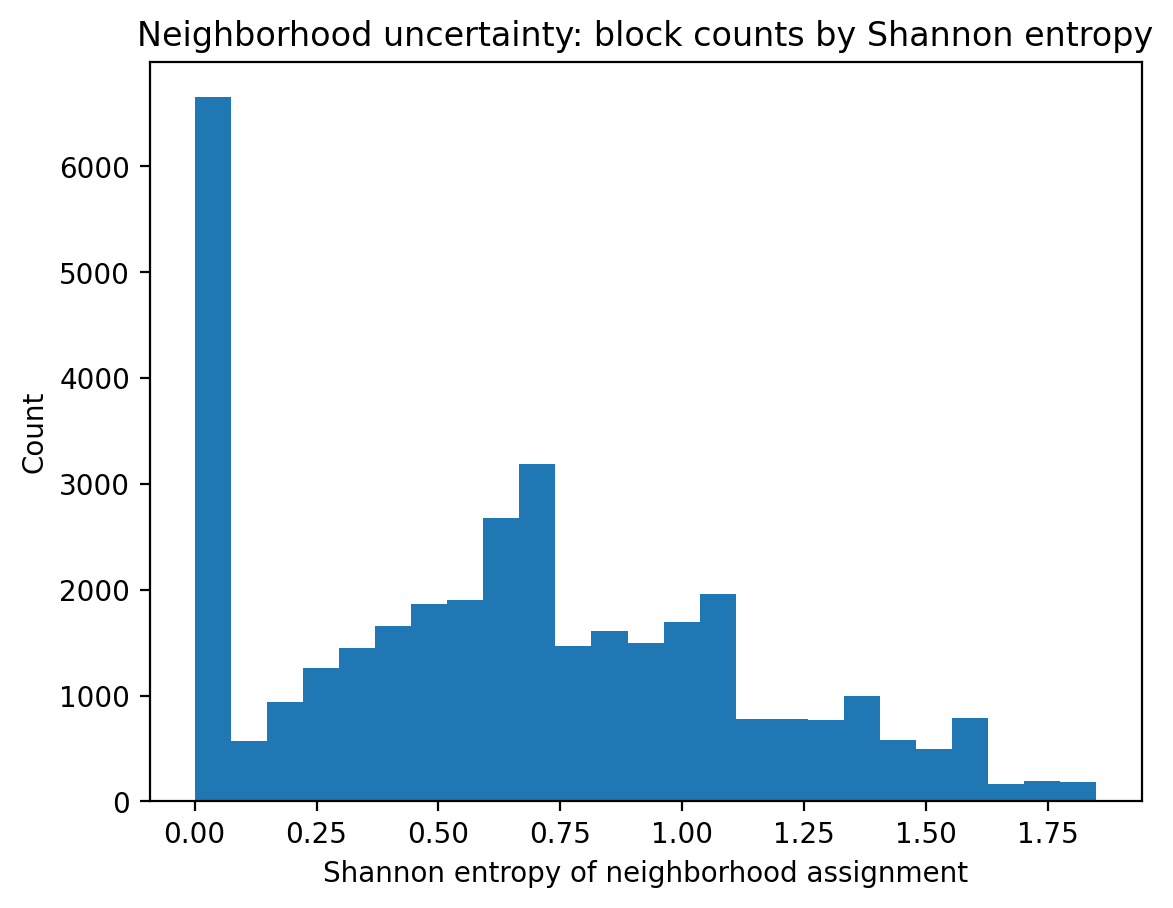

In [22]:
plt.hist(block_entropies.values(), bins=25)
plt.title("Neighborhood uncertainty: block counts by Shannon entropy")
plt.xlabel("Shannon entropy of neighborhood assignment")
plt.ylabel("Count")
plt.show()

In [23]:
block_gdf["entropy"] = block_entropies
nyc_gdf = block_gdf.loc[block_entropies.keys()].reset_index()

In [24]:
nyc_gdf.head(5)

,GEOID20,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry,entropy
0,360850323001008,36,085,032300,1008,1000000US360850323001008,Block1008,G5040,U,63217,S,33899,0,+40.6347918,-074.1940734,0,0,"POLYGON ((-74.19589 40.63525, -74.19527 40.636...",0.692755
1,360850323001007,36,085,032300,1007,1000000US360850323001007,Block1007,G5040,U,63217,S,0,15774,+40.6351631,-074.1934565,0,0,"POLYGON ((-74.19511 40.63644, -74.19496 40.636...",0.692697
2,360850323001005,36,085,032300,1005,1000000US360850323001005,Block1005,G5040,U,63217,S,352270,0,+40.6376836,-074.1891917,0,0,"POLYGON ((-74.19313 40.63919, -74.19037 40.640...",1.090573
3,360850323001006,36,085,032300,1006,1000000US360850323001006,Block1006,G5040,U,63217,S,93574,0,+40.6360535,-074.1919253,0,0,"POLYGON ((-74.19476 40.63705, -74.19461 40.637...",1.094185
4,360850323001011,36,085,032300,1011,1000000US360850323001011,Block1011,G5040,U,63217,S,213124,0,+40.6330968,-074.1884338,0,0,"POLYGON ((-74.19265 40.63476, -74.19253 40.635...",1.093771


In [25]:
top_neighborhoods = submissions_gdf["neighborhood"].value_counts().head(100)
top_neighborhoods

,count
neighborhood,
Upper West Side,2095
Park Slope,1033
Upper East Side,1009
East Village,847
West Village,669
...,...
Bensonhurst,41
Kew Gardens,40
East Elmhurst,40


In [26]:
neighborhood_blocks = {neighborhood: [] for neighborhood in top_neighborhoods.keys()}
for geoid, weights in block_weights.items():
    for neighborhood, weight in weights.items():
        if neighborhood in neighborhood_blocks and weight > 0.3:  # increase this cutoff to tighten boundaries
            neighborhood_blocks[neighborhood].append(geoid)

In [27]:
neighborhood_geos = {
    name: block_gdf.loc[geoids].dissolve().geometry
    for name, geoids in neighborhood_blocks.items()
}

And so we'll finish this notebook with a Folium map that plots the "core" neighborhoods (for the threshold you chose above).  And this should also have a checkbox in the upper right that lets you turn on and off a heatmap of the entropy score so you can see where there's the most label controversy!

In [28]:
entropy_map = folium.Map(
    [40.65, -73.95],
    zoom_start=12,
    tiles="Cartodb Positron",
)
colors = ['#0099cd', '#ffca5d', '#00cd99', '#99cd00', '#cd0099', '#aa44ef', '#8dd3c7', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#bc80bd', '#ccebc5', '#ffed6f', '#ffffb3', '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#b15928', '#64ffda', '#00B8D4', '#A1887F', '#76FF03', '#DCE775', '#B388FF', '#FF80AB', '#D81B60', '#26A69A', '#FFEA00', '#6200EA']

folium.Choropleth(
    geo_data=nyc_gdf,
    data=nyc_gdf,
    columns=["GEOID20", "entropy"],
    key_on="feature.properties.GEOID20",
    name="Neighborhood uncertainty (Shannon entropy)",
    fill_color="OrRd",
    line_opacity=0.2,
    fill_opacity=0.5,
    show=False,
).add_to(entropy_map)

for idx, (neighborhood, geos) in enumerate(neighborhood_geos.items()):
    if len(geos) > 0:
        for geo in geos:
            if isinstance(geo, MultiPolygon):
                for part in geo.geoms:
                    folium.Polygon(
                        [(y, x) for x, y in part.exterior.coords],
                        weight=6,
                        tooltip=neighborhood,
                        color=colors[idx % len(colors)],
                    ).add_to(entropy_map)
            else:
                folium.Polygon(
                    [(y, x) for x, y in geo.exterior.coords],
                    weight=6,
                    tooltip=neighborhood,
                    color=colors[idx % len(colors)],
                ).add_to(entropy_map)

folium.LayerControl(collapsed=False).add_to(entropy_map)

In [ ]:
entropy_map

#Homework 9 -- None!
